In [1]:
import contextlib
import os
import sys

from tqdm import  tqdm

import pandas as pd

from skcriteria.ranksrev import RankInvariantChecker, RankTransitivityChecker

import all_pipelines

import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)


In [2]:
def get_data():
    rows = []
    for pipe_name in all_pipelines.list_available_pipelines():
        pipes, dm = all_pipelines.get_pipeline_and_data(pipe_name)
        if not isinstance(pipes, dict):
            pipes = {pipe_name.split("_", 1)[0].upper(): pipes}
        for method, pipe in pipes.items():
            print(method, pipe_name)
            ric = RankInvariantChecker(pipe, allow_missing_alternatives=True, random_state=42)
            rtc = RankTransitivityChecker(pipe, allow_missing_alternatives=True)
            
            
            rrt1 = ric.evaluate(dm)
            rtt23 = rtc.evaluate(dm)
            
            row = {
                "pipe_name": pipe_name,
                "method": method,
                "dm": pipe_name.split("_", 1)[1],
                "alternatives": len(dm.alternatives),
                "criteria": len(dm.criteria),
                "rrt1_opr": rrt1.e_.opr,
                "rrt1_rd": rrt1.e_.rd,
                "rtt23_test_criterion_2": rtt23.e_.test_criterion_2,
                "rtt23_test_criterion_3": rtt23.e_.test_criterion_3,
                "rtt23_transitivity_break_rate": rtt23.e_.transitivity_break_rate,
                "rtt23_mpr": rtt23.e_.mpr,


                
            }
            rows.append(row)

    df = pd.DataFrame(rows)
    df.set_index("pipe_name", inplace=True, drop=True)

    return df

df = get_data()

CODAS codas_badi2017
CODAS codas_badi2018
CODAS codas_baki2022
CODAS codas_bakir2018
CODAS codas_turskis2016
COPRAS copras_uysal2022assistants
COPRAS copras_wieckowski2022criteriamethodscomparison
EDAS edas_ersoy2021
EDAS edas_karabasevic2018
EDAS edas_mathew2018
EDAS edas_sharma2021
ERVD ervd_shyur2015multiple
MABAC mabac_pamucar2014
RatioMOORA moora_kracka2010ranking
ReferencePointMOORA moora_kracka2010ranking
FullMultiplicativeForm moora_kracka2010ranking
MultiMOORA moora_kracka2010ranking
OCRA ocra_isik2016
SimplifiedPROBID probid_wang2021original
PROBID probid_wang2021original
RAM ram_sotoudeh2023
SPOTIS spotis_dezert2020_example_b
TOPSIS topsis_tzeng2011multiple
VIKOR vikor_opricovic2004compromise
VIKOR vikor_opricovic2007extended
VIKOR vikor_tzeng2011
WASPAS waspas_chakraborty2015applications


In [3]:
display(df)
display(df.shape)

,method,dm,alternatives,criteria,rrt1_opr,rrt1_rd,rtt23_test_criterion_2,rtt23_test_criterion_3,rtt23_transitivity_break_rate,rtt23_mpr
pipe_name,,,,,,,,,,
codas_badi2017,CODAS,badi2017,6,4,1.0,0.0,True,True,0.000000,1
codas_badi2018,CODAS,badi2018,5,5,1.0,0.0,True,True,0.000000,1
codas_baki2022,CODAS,baki2022,4,8,1.0,0.0,True,True,0.000000,1
codas_bakir2018,CODAS,bakir2018,11,7,1.0,0.0,True,False,0.000000,1
codas_turskis2016,CODAS,turskis2016,14,6,1.0,0.0,True,False,0.000000,1
copras_uysal2022assistants,COPRAS,uysal2022assistants,5,7,1.0,0.0,True,False,0.000000,1
copras_wieckowski2022criteriamethodscomparison,COPRAS,wieckowski2022criteriamethodscomparison,7,10,1.0,0.0,True,True,0.000000,1
edas_ersoy2021,EDAS,ersoy2021,6,6,1.0,0.0,True,True,0.000000,1
edas_karabasevic2018,EDAS,karabasevic2018,6,7,1.0,0.0,True,True,0.000000,1


(27, 10)

---
---

## Literature-Wide Audit: RRT1-RRT3 Across 27 Published MCDM Examples

Unlike the single deep-dive in `case1`, this experiment audits rank-reversal robustness at scale. `all_pipelines.py`/`all_dm.py` reproduce, pipeline-for-pipeline and matrix-for-matrix, the *exact* worked examples used by 20 published MCDM methods (CODAS, COPRAS, EDAS, ERVD, MABAC, the four MOORA variants, OCRA, PROBID/SimplifiedPROBID, RAM, SPOTIS, TOPSIS, VIKOR, WASPAS) across 27 pipeline/dataset combinations, including each paper's own preprocessing (scalers, objective inverters, method-specific kwargs, etc.). Because these are the very examples the original authors chose to showcase their methods, any rank-reversal vulnerability found here cannot be dismissed as an artificial or adversarial construction — it is present in the literature's own reference cases.

We apply the same two families of tests as in `case1` to every pipeline: **RRT1** (`RankInvariantChecker`, robustness of the top choice to controlled degradations) and **RRT2/RRT3** (`RankTransitivityChecker`, transitivity and recomposition-consistency of the pairwise dominance tournament). RRT2 and RRT3 test two logically different things, and it is worth being explicit about why a pipeline can pass one and fail the other: RRT2 only asks whether the pairwise dominance tournament is acyclic; RRT3 asks whether the ranking *recomposed* from that tournament matches what the same method concludes when it evaluates every alternative *together*. Most MCDM aggregators are context-dependent — their normalization constants or ideal/anti-ideal reference points are computed from every alternative present in the matrix — so a method can produce a perfectly transitive, cycle-free tournament and still fail RRT3, simply because scoring "all together" uses a different normalization context than scoring "one pair at a time." This is a violation of independence of irrelevant alternatives (IIA), not a logical inconsistency, and it is precisely why RRT3 can catch failures that RRT2 structurally cannot see.

### 1. Pass Rates Across the Benchmark

We first summarize, across all 27 pipelines, the fraction that pass each criterion: RRT1 (`rrt1_opr == 1`, the top choice is never displaced by any mutation), RRT2 (`test_criterion_2`, the pairwise dominance graph is acyclic) and RRT3 (`test_criterion_3`, the recomposed ranking matches the original).

/tmp/ipykernel_41601/1170154587.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pass_rates.index, y=pass_rates.values, palette=rrt_colors, ax=ax)


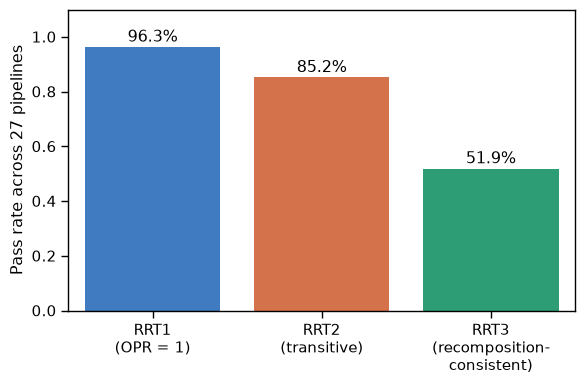

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("paper", font_scale=1.2, rc={"lines.linewidth": 1.5})

pass_rates = pd.Series({
    "RRT1\n(OPR = 1)": (df["rrt1_opr"] == 1).mean(),
    "RRT2\n(transitive)": df["rtt23_test_criterion_2"].mean(),
    "RRT3\n(recomposition-\nconsistent)": df["rtt23_test_criterion_3"].mean(),
})

rrt_colors = ["#2a78d6", "#eb6834", "#1baf7a"]  # RRT1, RRT2, RRT3

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=pass_rates.index, y=pass_rates.values, palette=rrt_colors, ax=ax)
ax.set_ylim(0, 1.1)
ax.set_ylabel(f"Pass rate across {len(df)} pipelines")
ax.set_xlabel("")

for i, v in enumerate(pass_rates.values):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center")

fig.tight_layout()
fig.savefig("../imgs/case2/rrt_pass_rates.png", dpi=300)
plt.show()

**RRT1 passes almost everywhere (96.3%, 26/27)** — the single exception is `ReferencePointMOORA` on `kracka2010ranking` (OPR = 0.6), the only pipeline in the whole benchmark whose top choice is not fully robust to degradation. **RRT2 passes for 85.2% (23/27)** of pipelines — a clean, cycle-free pairwise tournament is the common case, but four pipelines (MABAC, PROBID, SimplifiedPROBID, and one VIKOR variant) do contain genuine intransitive triples. The gap becomes much more visible at **RRT3, which passes for only 51.9% (14/27)** — under half of the published examples produce a ranking that is actually consistent with its own pairwise decomposition. This confirms, at scale, the point discussed above: transitivity (RRT2) is common, but recomposition-consistency (RRT3) is not — most of that additional failure comes from pipelines that are perfectly transitive yet still get reshuffled once every alternative is scored together.

----

### 2. Per-Pipeline Pass/Fail Breakdown

To see exactly *which* pipelines drive these failure rates, we plot a pass/fail matrix (pipelines x criterion), sorted so that failures accumulate visibly rather than being scattered.

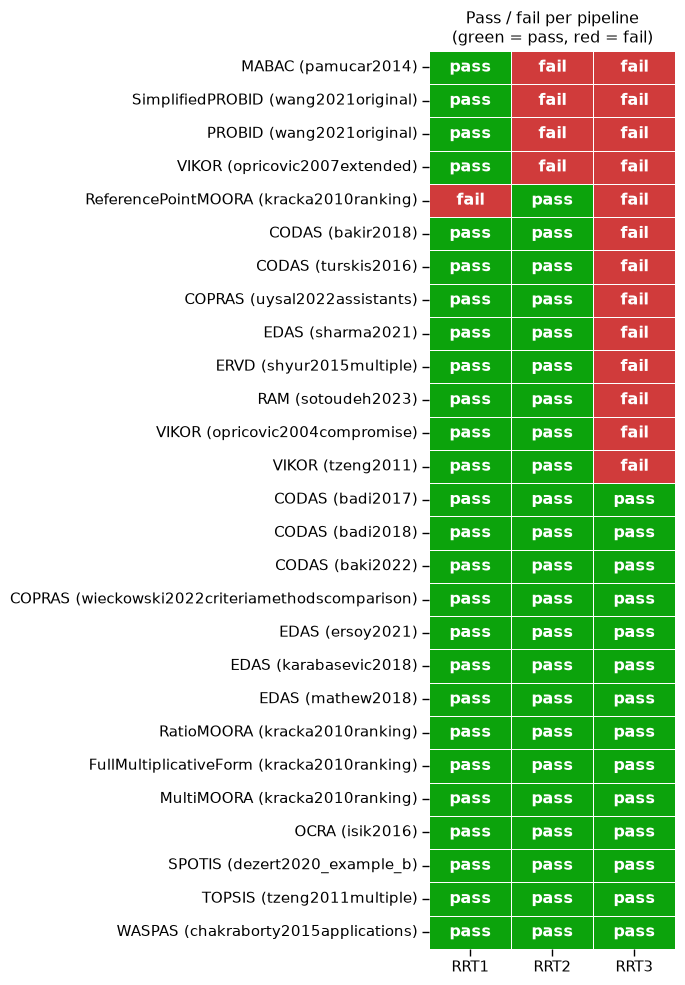

In [5]:
from matplotlib.colors import ListedColormap

pass_df = pd.DataFrame({
    "RRT1": (df["rrt1_opr"] == 1).astype(int),
    "RRT2": df["rtt23_test_criterion_2"].astype(int),
    "RRT3": df["rtt23_test_criterion_3"].astype(int),
})
pass_df.index = df["method"] + " (" + df["dm"] + ")"
pass_df = pass_df.sort_values(["RRT3", "RRT2", "RRT1"])

labels = pass_df.replace({1: "pass", 0: "fail"})
status_cmap = ListedColormap(["#d03b3b", "#0ca30c"])  # 0=fail (red), 1=pass (green)

fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(pass_df, cmap=status_cmap, cbar=False, linewidths=0.5, linecolor="white",
            annot=labels, fmt="", annot_kws={"color": "white", "fontweight": "bold"},
            vmin=0, vmax=1, ax=ax)
ax.set_title("Pass / fail per pipeline\n(green = pass, red = fail)")
ax.set_ylabel("")

fig.tight_layout()
fig.savefig("../imgs/case2/rrt_pass_fail_heatmap.png", dpi=300)
plt.show()

The four **RRT2 failures** are concentrated in methods built around reference regions or boundary distances computed from the whole alternative set: `MABAC (pamucar2014)` is by far the most severe (transitivity break rate 0.5, i.e. half of all theoretically possible 3-cycles are actually present, with `mpr = 5040` distinct linear extensions consistent with its dominance graph), followed by `PROBID`/`SimplifiedPROBID (wang2021original)` (break rate 0.036, `mpr = 24`) and `VIKOR (opricovic2007extended)` (break rate 0.125, `mpr = 6`) — all four also fail RRT3, since a cyclic tournament can never be recomposed into the original ranking. The sole **RRT1 failure**, `ReferencePointMOORA (kracka2010ranking)`, stands out for a different reason: `RatioMOORA`, `FullMultiplicativeForm` and `MultiMOORA` are all perfectly robust on the *exact same* decision matrix, which pins the fragility on the aggregator itself rather than the data.

The most numerous group, however, is the **nine pipelines that pass RRT2 but fail RRT3** — `codas_bakir2018`, `codas_turskis2016`, `copras_uysal2022assistants`, `edas_sharma2021`, `ervd_shyur2015multiple`, `ReferencePointMOORA (kracka2010ranking)`, `ram_sotoudeh2023`, `vikor_opricovic2004compromise` and `vikor_tzeng2011`. None of these show a single intransitive triple, yet the ranking recomposed from pairwise comparisons still disagrees with the original — the IIA-driven pattern discussed above, where adding "irrelevant" alternatives back into the matrix silently shifts the normalization or reference point used to score every pair. This is the largest single failure mode in the entire audit, and it is invisible to RRT2 by construction.

### 3. Pass Rate vs. Problem Size (Criteria and Alternatives)

Does the size of the decision problem predict how likely a pipeline is to pass RRT1-RRT3? We bin the 27 pipelines into four roughly balanced groups by number of criteria and, separately, by number of alternatives, and plot the pass rate of each test within each bin as a line with markers, side by side. With only 27 pipelines these bins are necessarily coarse, and each rate should be read as descriptive rather than a statistically validated trend.

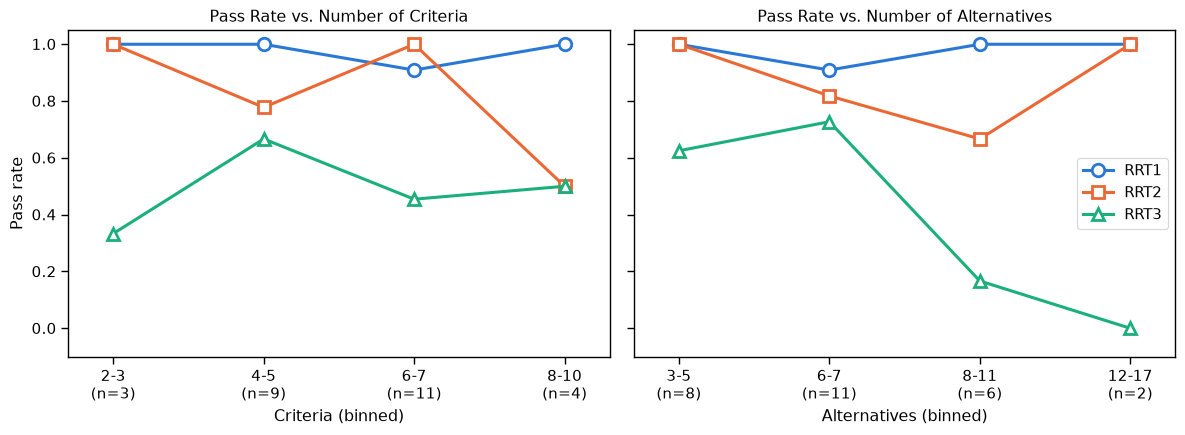

In [6]:
bin_df = pd.DataFrame({
    "alternatives": df["alternatives"],
    "criteria": df["criteria"],
    "RRT1": (df["rrt1_opr"] == 1),
    "RRT2": df["rtt23_test_criterion_2"],
    "RRT3": df["rtt23_test_criterion_3"],
})

criteria_edges, criteria_labels = [1, 3, 5, 7, 10], ["2-3", "4-5", "6-7", "8-10"]
alt_edges, alt_labels = [2, 5, 7, 11, 17], ["3-5", "6-7", "8-11", "12-17"]

bin_df["criteria_bin"] = pd.cut(bin_df["criteria"], bins=criteria_edges, labels=criteria_labels)
bin_df["alt_bin"] = pd.cut(bin_df["alternatives"], bins=alt_edges, labels=alt_labels)

def bin_pass_rates(bin_col, labels):
    long = bin_df.melt(id_vars=[bin_col], value_vars=["RRT1", "RRT2", "RRT3"],
                        var_name="test", value_name="passed")
    summary = long.groupby([bin_col, "test"], observed=True)["passed"].mean().reset_index()
    counts = bin_df[bin_col].value_counts()
    summary["label"] = (summary[bin_col].astype(str)
                         + "\n(n=" + summary[bin_col].map(counts).astype(str) + ")")
    order = [f"{lbl}\n(n={counts.get(lbl, 0)})" for lbl in labels]
    return summary, order

criteria_summary, criteria_order = bin_pass_rates("criteria_bin", criteria_labels)
alt_summary, alt_order = bin_pass_rates("alt_bin", alt_labels)

styles = {
    "RRT1": dict(color="#2a78d6", marker="o"),
    "RRT2": dict(color="#eb6834", marker="s"),
    "RRT3": dict(color="#1baf7a", marker="^"),
}

def plot_bins(ax, summary, order, title, xlabel, ylabel):
    x = range(len(order))
    for test in ["RRT1", "RRT2", "RRT3"]:
        sub = summary[summary["test"] == test].set_index("label").reindex(order)
        ax.plot(x, sub["passed"], label=test, markersize=9, linewidth=2.2,
                markerfacecolor="white", markeredgewidth=2, **styles[test])
    ax.set_xticks(list(x))
    ax.set_xticklabels(order)
    ax.set_xlim(-0.3, len(order) - 0.7)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_ylim(-0.1, 1.05)
    ax.legend(loc="center right")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

plot_bins(axes[0], criteria_summary, criteria_order,
          "Pass Rate vs. Number of Criteria", "Criteria (binned)", "Pass rate")
plot_bins(axes[1], alt_summary, alt_order,
          "Pass Rate vs. Number of Alternatives", "Alternatives (binned)", "")

axes[0].get_legend().remove()

fig.tight_layout()
fig.savefig("../imgs/case2/rrt_pass_rate_vs_size.png", dpi=300)
plt.show()

**By number of criteria**, the finer bins actually separate the offenders more cleanly than a coarser split would: RRT2 is perfect (100%) in the 6-7 bin, but drops to 77.8% in the 4-5 bin (driven entirely by `PROBID`/`SimplifiedPROBID`, both with 5 criteria) and to 50% in the 8-10 bin (`MABAC`, 10 criteria, and `VIKOR/opricovic2007extended`, 8 criteria, are 2 of its 4 pipelines). As before, this tracks *which specific methods* land in each bin rather than a smooth effect of criteria count.

**By number of alternatives**, splitting the old "8-17" bin in two makes the collapse even sharper: RRT3 passes 62.5% of the time at 3-5 alternatives, ticks up to 72.7% at 6-7, then falls to 16.7% at 8-11 and **all the way to 0% at 12-17** — the two largest pipelines in the whole benchmark, `CODAS (turskis2016, 14 alternatives)` and `ERVD (shyur2015multiple, 17 alternatives)`, both fail RRT3 despite passing RRT1 and RRT2 perfectly. RRT1 and RRT2 stay high across every bin, so the size effect is specific to recomposition-consistency: the more alternatives are present, the more likely some extreme value is to shift the normalization or ideal-point reference used to score every pair, exactly the IIA mechanism discussed above.